In [1]:
# ============================================================
# CELL 1  (unchanged)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.signal import welch
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

In [2]:
# ============================================================
# CELL 2  (unchanged)
# ============================================================
eeg    = np.load("eeg_ml.npy")     # Expected shape: (n_samples, 32, n_timepoints)
labels = np.load("labels_ml.npy")  # Expected shape: (n_samples, 4)

print("EEG shape    :", eeg.shape)
print("Labels shape :", labels.shape)

EEG shape    : (1280, 32, 8064)
Labels shape : (1280, 4)


In [3]:
# ============================================================
# CELL 3  (REPLACES old "Extract valence ... binarise" cell)
# ============================================================
# Mapping of DEAP label columns -> emotion dimensions
EMOTIONS = {
    "Valence"   : 0,
    "Arousal"   : 1,
    "Dominance" : 2,
    "Liking"    : 3,
}

In [4]:
# ============================================================
# CELL 4  (unchanged — Band Power feature extraction)
# ============================================================
# EEG sampling frequency (Hz)
FS = 128

# Frequency band definitions (Hz)
BANDS = {
    "Delta" : (0.5, 4),
    "Theta" : (4,   8),
    "Alpha" : (8,  13),
    "Beta"  : (13, 30),
    "Gamma" : (30, 45),
}


def band_power(psd, freqs, fmin, fmax):
    """Return mean PSD power within [fmin, fmax] Hz."""
    idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
    return np.mean(psd[idx]) if idx.size > 0 else 0.0


def extract_band_power_features(eeg_data, fs=FS, bands=BANDS):
    """
    Extract band power features for every sample and channel.

    Parameters
    ----------
    eeg_data : np.ndarray  shape (n_samples, n_channels, n_timepoints)
    fs       : int         sampling frequency in Hz
    bands    : dict        {band_name: (fmin, fmax)}

    Returns
    -------
    np.ndarray  shape (n_samples, n_channels * n_bands)
    """
    n_samples, n_channels, _ = eeg_data.shape
    n_bands  = len(bands)
    features = np.zeros((n_samples, n_channels * n_bands))

    for i, sample in enumerate(eeg_data):
        vec = []
        for ch in range(n_channels):
            freqs, psd = welch(sample[ch], fs=fs, nperseg=fs * 2)
            for fmin, fmax in bands.values():
                vec.append(band_power(psd, freqs, fmin, fmax))
        features[i] = vec

    return features


X = extract_band_power_features(eeg)
print("Feature matrix shape :", X.shape)   # (n_samples, 160)

Feature matrix shape : (1280, 160)


In [5]:
# ============================================================
# CELL 5  (REPLACES old Cells 4–19 — full per-emotion pipeline
#          as a single reusable function)
# ============================================================
def run_pipeline_for_emotion(emotion_name, y):
    """
    Full Band-Power EEG pipeline for a single emotion dimension:
    train/test split -> scaling -> RF -> metrics -> CV -> plots ->
    feature importance -> channel ranking -> channel-reduction study
    (32/16/8/4) -> best-model saving.

    Returns a dict with everything needed for the cross-emotion
    summary tables / comparison plots.
    """
    print(f"\n{'#'*70}")
    print(f"#  RUNNING PIPELINE FOR: {emotion_name.upper()}")
    print(f"{'#'*70}")

    tag = emotion_name.lower()

    # --- Train/Test split (32-channel baseline) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("Train set :", X_train.shape)
    print("Test  set :", X_test.shape)

    # --- Scaling ---
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    joblib.dump(scaler, f"{tag}_band_scaler_32ch.pkl")
    print(f"Scaler saved → {tag}_band_scaler_32ch.pkl")

    # --- Train RF (32-channel baseline) ---
    model = RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    print("Training complete.")

    # --- Evaluate on hold-out test set ---
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=[f"Low {emotion_name}", f"High {emotion_name}"]))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # --- 5-Fold CV (32-channel, full X) ---
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_model = RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
    )
    cv_scores = cross_val_score(cv_model, X, y, cv=cv, scoring="accuracy")
    print(f"Fold Scores   : {np.round(cv_scores, 4)}")
    print(f"Mean Accuracy : {cv_scores.mean():.4f}")
    print(f"Std Deviation : {cv_scores.std():.4f}")

    # --- Confusion matrix plot (32-channel baseline) ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[f"Low {emotion_name}", f"High {emotion_name}"],
                yticklabels=[f"Low {emotion_name}", f"High {emotion_name}"])
    plt.title(f"Confusion Matrix — Band Power Features (32 Channels) | {emotion_name}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_band_{tag}.png", dpi=150)
    plt.show()

    # --- CV bar chart ---
    plt.figure(figsize=(7, 4))
    plt.bar(range(1, 6), cv_scores * 100, color="steelblue", edgecolor="black")
    plt.axhline(cv_scores.mean() * 100, color="red", linestyle="--",
                label=f"Mean: {cv_scores.mean() * 100:.2f}%")
    plt.xlabel("Fold"); plt.ylabel("Accuracy (%)")
    plt.title(f"5-Fold Cross Validation Accuracy | {emotion_name}")
    plt.legend(); plt.tight_layout()
    plt.savefig(f"cv_scores_band_{tag}.png", dpi=150)
    plt.show()

    # --- Feature importance -> channel ranking ---
    n_bands    = len(BANDS)
    n_channels = eeg.shape[1]
    band_names = list(BANDS.keys())
    feature_names = [f"Ch{ch+1}_{band}" for ch in range(n_channels) for band in band_names]

    channel_scores = {}
    for ch in range(n_channels):
        start = ch * n_bands
        score = model.feature_importances_[start:start + n_bands].sum()
        channel_scores[f"Channel_{ch + 1}"] = score

    channel_ranking = (
        pd.DataFrame(channel_scores.items(), columns=["Channel", "Score"])
        .sort_values("Score", ascending=False)
        .reset_index(drop=True)
    )
    print(channel_ranking)

    # --- Channel importance plot ---
    plt.figure(figsize=(14, 5))
    sns.barplot(data=channel_ranking, x="Channel", y="Score",
                order=channel_ranking["Channel"], palette="coolwarm")
    plt.xticks(rotation=90)
    plt.xlabel("EEG Channel"); plt.ylabel("Total Importance Score")
    plt.title(f"EEG Channel Importance — Band Power Features | {emotion_name}")
    plt.tight_layout()
    plt.savefig(f"channel_importance_band_{tag}.png", dpi=150)
    plt.show()

    # --- Top-N channel index lists ---
    ranked_ch_nums = (
        channel_ranking["Channel"].str.extract(r"(\d+)").astype(int)[0].tolist()
    )

    def top_channel_idx(ranked_nums, n):
        return [c - 1 for c in ranked_nums[:n]]

    top32_idx = top_channel_idx(ranked_ch_nums, 32)
    top16_idx = top_channel_idx(ranked_ch_nums, 16)
    top8_idx  = top_channel_idx(ranked_ch_nums, 8)
    top4_idx  = top_channel_idx(ranked_ch_nums, 4)

    print("Top 4  channels:", [c + 1 for c in top4_idx])
    print("Top 8  channels:", [c + 1 for c in top8_idx])
    print("Top 16 channels:", [c + 1 for c in top16_idx])

    # --- Channel-reduction evaluation (32/16/8/4) ---
    configs = {
        "Top 32 Channels": top32_idx,
        "Top 16 Channels": top16_idx,
        "Top 8 Channels" : top8_idx,
        "Top 4 Channels" : top4_idx,
    }

    results  = []
    cm_store = {}

    for config_name, ch_idx in configs.items():
        eeg_sub = eeg[:, ch_idx, :]
        X_sub   = extract_band_power_features(eeg_sub)

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_sub, y, test_size=0.2, random_state=42, stratify=y
        )

        sc   = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        clf = RandomForestClassifier(
            n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
        )
        clf.fit(X_tr, y_tr)

        y_pr = clf.predict(X_te)
        cm_store[config_name] = confusion_matrix(y_te, y_pr)

        acc_c  = accuracy_score(y_te, y_pr)
        prec_c = precision_score(y_te, y_pr)
        rec_c  = recall_score(y_te, y_pr)
        f1_c   = f1_score(y_te, y_pr)

        cv_s = cross_val_score(
            RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                    random_state=42, n_jobs=-1),
            X_sub, y,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring="accuracy"
        )

        results.append({
            "Emotion"       : emotion_name,
            "Configuration" : config_name,
            "Channels"      : len(ch_idx),
            "Features"      : len(ch_idx) * n_bands,
            "Accuracy"      : round(acc_c,  4),
            "Precision"     : round(prec_c, 4),
            "Recall"        : round(rec_c,  4),
            "F1-Score"      : round(f1_c,   4),
            "CV Mean"       : round(cv_s.mean(), 4),
            "CV Std"        : round(cv_s.std(),  4),
        })

        print(f"\n{'='*52}")
        print(f"  {emotion_name} | {config_name}")
        print(f"{'='*52}")
        print(f"  Accuracy  : {acc_c:.4f}  |  Precision : {prec_c:.4f}")
        print(f"  Recall    : {rec_c:.4f}  |  F1-Score  : {f1_c:.4f}")
        print(f"  CV Accuracy : {cv_s.mean():.4f} ± {cv_s.std():.4f}")
        print(f"\n  Classification Report:")
        print(classification_report(y_te, y_pr,
              target_names=[f"Low {emotion_name}", f"High {emotion_name}"]))

    # --- Results table ---
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    # --- Accuracy / CV vs Channels plot ---
    ch_counts  = [r["Channels"] for r in results]
    accuracies = [r["Accuracy"] for r in results]
    cv_means   = [r["CV Mean"]  for r in results]
    cv_stds    = [r["CV Std"]   for r in results]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(ch_counts, accuracies, marker="o", color="steelblue", linewidth=2)
    for x_, v in zip(ch_counts, accuracies):
        axes[0].annotate(f"{v:.4f}", (x_, v), textcoords="offset points", xytext=(0, 8), ha="center")
    axes[0].set_xticks(ch_counts)
    axes[0].set_xlabel("Number of Channels"); axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"Hold-out Accuracy vs Channels | {emotion_name}")
    axes[0].grid(True)

    axes[1].errorbar(ch_counts, cv_means, yerr=cv_stds, marker="o",
                      color="darkorange", capsize=5, linewidth=2)
    for x_, v in zip(ch_counts, cv_means):
        axes[1].annotate(f"{v:.4f}", (x_, v), textcoords="offset points", xytext=(0, 8), ha="center")
    axes[1].set_xticks(ch_counts)
    axes[1].set_xlabel("Number of Channels"); axes[1].set_ylabel("CV Mean Accuracy")
    axes[1].set_title(f"5-Fold CV Accuracy vs Channels | {emotion_name}")
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"accuracy_vs_channels_band_{tag}.png", dpi=150)
    plt.show()

    # --- Metrics comparison bar chart ---
    metrics_list = ["Accuracy", "Precision", "Recall", "F1-Score"]
    x_pos = np.arange(len(results)); width = 0.2

    fig, ax = plt.subplots(figsize=(13, 5))
    for i, metric in enumerate(metrics_list):
        vals = [r[metric] for r in results]
        bars = ax.bar(x_pos + i * width, vals, width, label=metric)
        ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)

    ax.set_xticks(x_pos + width * 1.5)
    ax.set_xticklabels([r["Configuration"] for r in results])
    ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
    ax.set_title(f"Evaluation Metrics — All Channel Configurations | {emotion_name}")
    ax.legend(); plt.tight_layout()
    plt.savefig(f"metrics_comparison_band_{tag}.png", dpi=150)
    plt.show()

    # --- Confusion matrices grid (all configs) ---
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, (config_name, cm_c) in zip(axes, cm_store.items()):
        sns.heatmap(
            cm_c, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Low", "High"],
            yticklabels=["Low", "High"]
        )
        ax.set_title(config_name)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")

    plt.suptitle(f"Confusion Matrices — Band Power | All Channel Configurations | {emotion_name}",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f"confusion_matrices_all_band_{tag}.png", dpi=150)
    plt.show()

    # --- Retrain + save BEST model/scaler for this emotion ---
    best = max(results, key=lambda r: r["CV Mean"])
    print(f"Best Configuration : {best['Configuration']}")
    print(f"CV Mean Accuracy   : {best['CV Mean']:.4f} ± {best['CV Std']:.4f}")
    print(f"Hold-out Accuracy  : {best['Accuracy']:.4f}")

    best_idx  = configs[best["Configuration"]]
    eeg_best  = eeg[:, best_idx, :]
    X_best    = extract_band_power_features(eeg_best)
    sc_best   = StandardScaler()
    X_best_sc = sc_best.fit_transform(X_best)

    best_model = RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
    )
    best_model.fit(X_best_sc, y)

    model_filename  = f"{tag}_band_model.pkl"
    scaler_filename = f"{tag}_band_scaler.pkl"

    joblib.dump(best_model, model_filename)
    joblib.dump(sc_best,    scaler_filename)

    print(f"\nSaved → {model_filename}")
    print(f"Saved → {scaler_filename}")

    return {
        "emotion"         : emotion_name,
        "results"         : results,
        "results_df"      : results_df,
        "channel_ranking" : channel_ranking,
        "cm_store"        : cm_store,
        "configs"         : configs,
        "baseline"        : {
            "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1,
            "CV Mean": cv_scores.mean(), "CV Std": cv_scores.std()
        },
        "best"            : best,
        "best_model"      : best_model,
        "best_scaler"     : sc_best,
        "model_filename"  : model_filename,
        "scaler_filename" : scaler_filename,
    }


Class distribution (Valence) : [572 708]  → [Low, High]

######################################################################
#  RUNNING PIPELINE FOR: VALENCE
######################################################################
Train set : (1024, 160)
Test  set : (256, 160)
Scaler saved → valence_band_scaler_32ch.pkl
Training complete.
Accuracy  : 0.5820
Precision : 0.6174
Recall    : 0.6479
F1-Score  : 0.6323

Classification Report:
              precision    recall  f1-score   support

 Low Valence       0.53      0.50      0.52       114
High Valence       0.62      0.65      0.63       142

    accuracy                           0.58       256
   macro avg       0.58      0.57      0.57       256
weighted avg       0.58      0.58      0.58       256

Confusion Matrix:
[[57 57]
 [50 92]]
Fold Scores   : [0.6211 0.6641 0.6602 0.6445 0.6523]
Mean Accuracy : 0.6484
Std Deviation : 0.0152


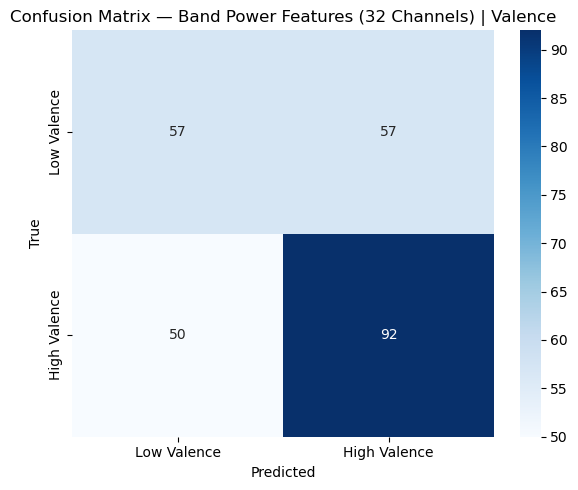

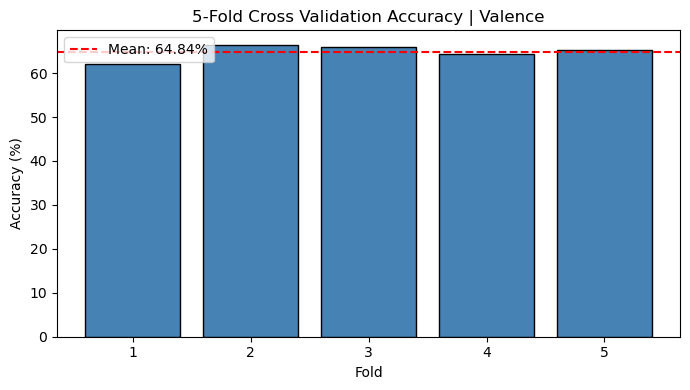

       Channel     Score
0   Channel_10  0.034864
1   Channel_30  0.034791
2   Channel_16  0.034464
3    Channel_6  0.034270
4   Channel_24  0.034118
5   Channel_32  0.034047
6    Channel_9  0.033928
7   Channel_29  0.033772
8   Channel_22  0.033630
9   Channel_21  0.032947
10   Channel_4  0.032842
11   Channel_7  0.032757
12  Channel_14  0.032031
13   Channel_2  0.031410
14  Channel_13  0.031161
15   Channel_1  0.031113
16  Channel_23  0.030946
17  Channel_15  0.030900
18  Channel_12  0.030819
19  Channel_17  0.030736
20  Channel_18  0.030343
21  Channel_19  0.029952
22   Channel_3  0.029873
23  Channel_27  0.029839
24  Channel_11  0.029392
25   Channel_8  0.029303
26  Channel_31  0.028752
27  Channel_26  0.028721
28  Channel_20  0.028584
29  Channel_25  0.028290
30  Channel_28  0.027734
31   Channel_5  0.023671


C:\Users\Sayantan\AppData\Local\Temp\ipykernel_21212\2008507769.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_ranking, x="Channel", y="Score",


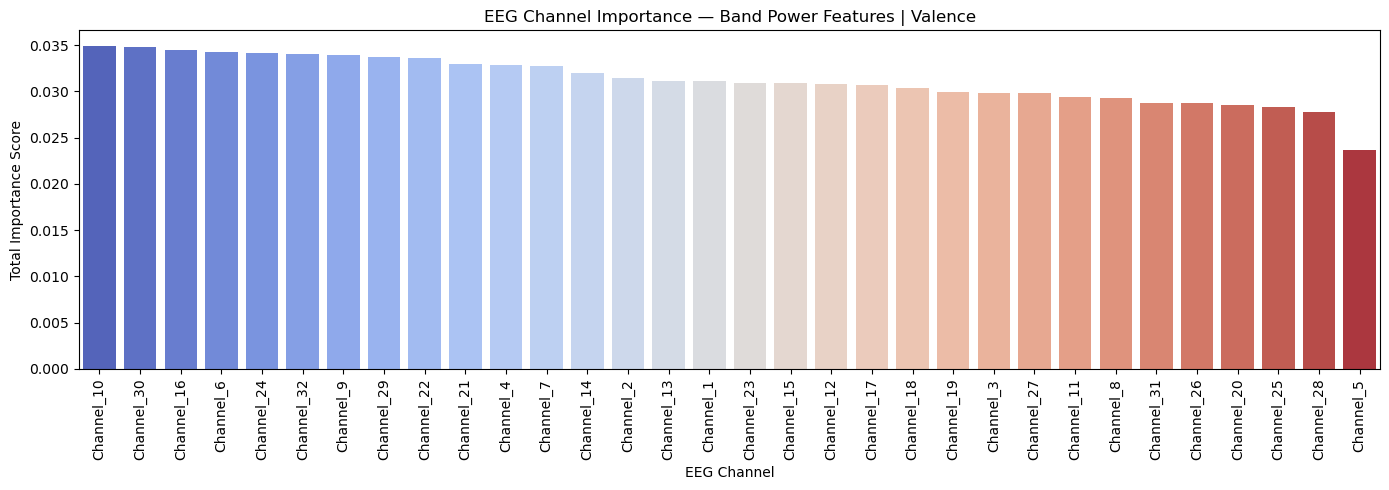

Top 4  channels: [10, 30, 16, 6]
Top 8  channels: [10, 30, 16, 6, 24, 32, 9, 29]
Top 16 channels: [10, 30, 16, 6, 24, 32, 9, 29, 22, 21, 4, 7, 14, 2, 13, 1]

  Valence | Top 32 Channels
  Accuracy  : 0.5938  |  Precision : 0.6284
  Recall    : 0.6549  |  F1-Score  : 0.6414
  CV Accuracy : 0.6461 ± 0.0174

  Classification Report:
              precision    recall  f1-score   support

 Low Valence       0.55      0.52      0.53       114
High Valence       0.63      0.65      0.64       142

    accuracy                           0.59       256
   macro avg       0.59      0.59      0.59       256
weighted avg       0.59      0.59      0.59       256


  Valence | Top 16 Channels
  Accuracy  : 0.5938  |  Precision : 0.6234
  Recall    : 0.6761  |  F1-Score  : 0.6486
  CV Accuracy : 0.6461 ± 0.0346

  Classification Report:
              precision    recall  f1-score   support

 Low Valence       0.55      0.49      0.52       114
High Valence       0.62      0.68      0.65       142

  

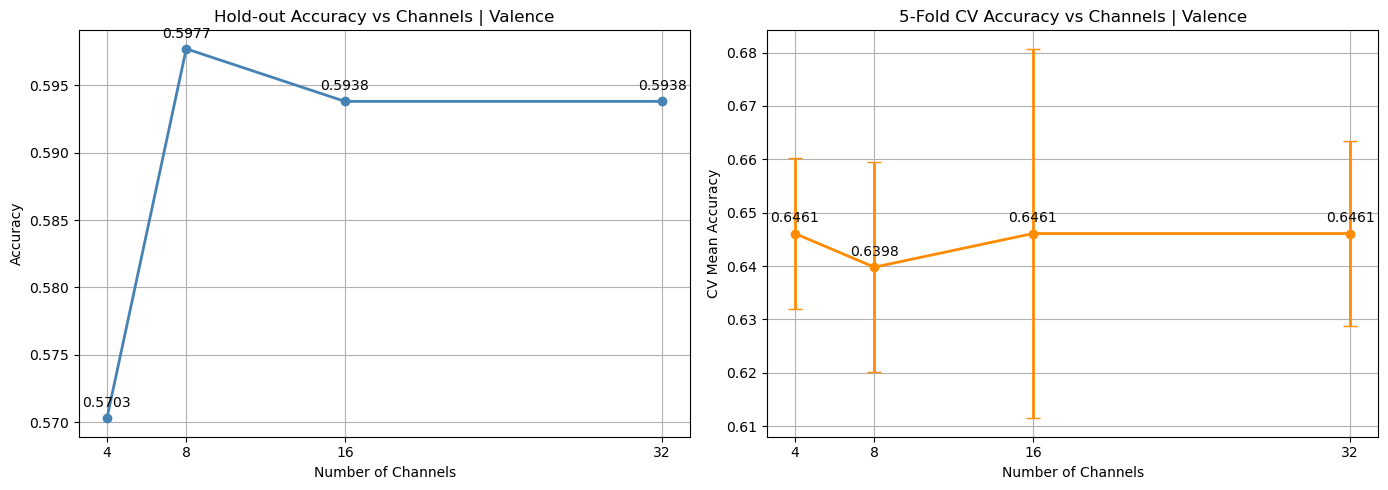

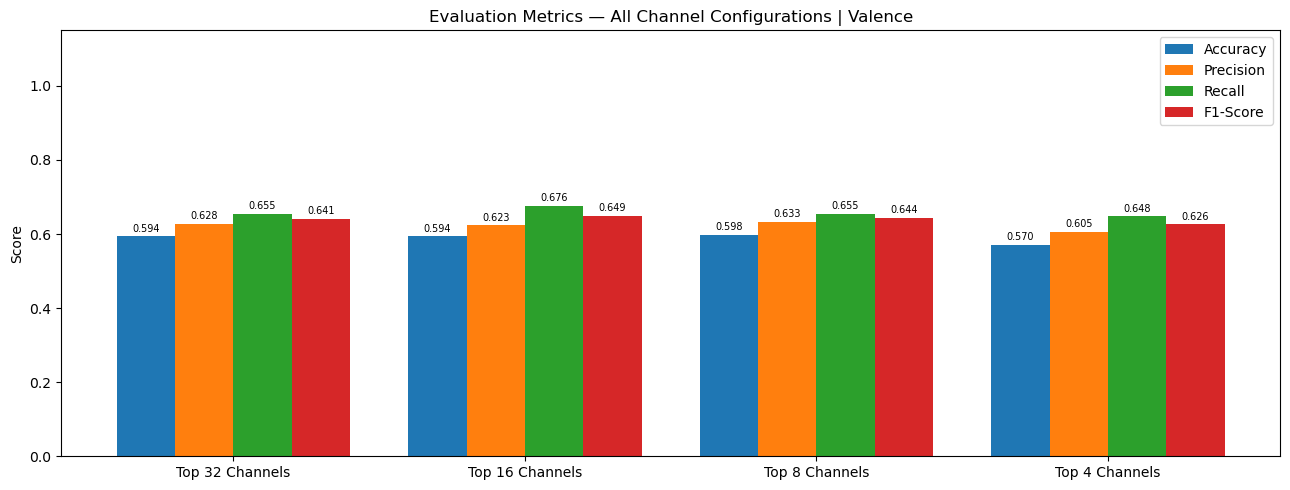

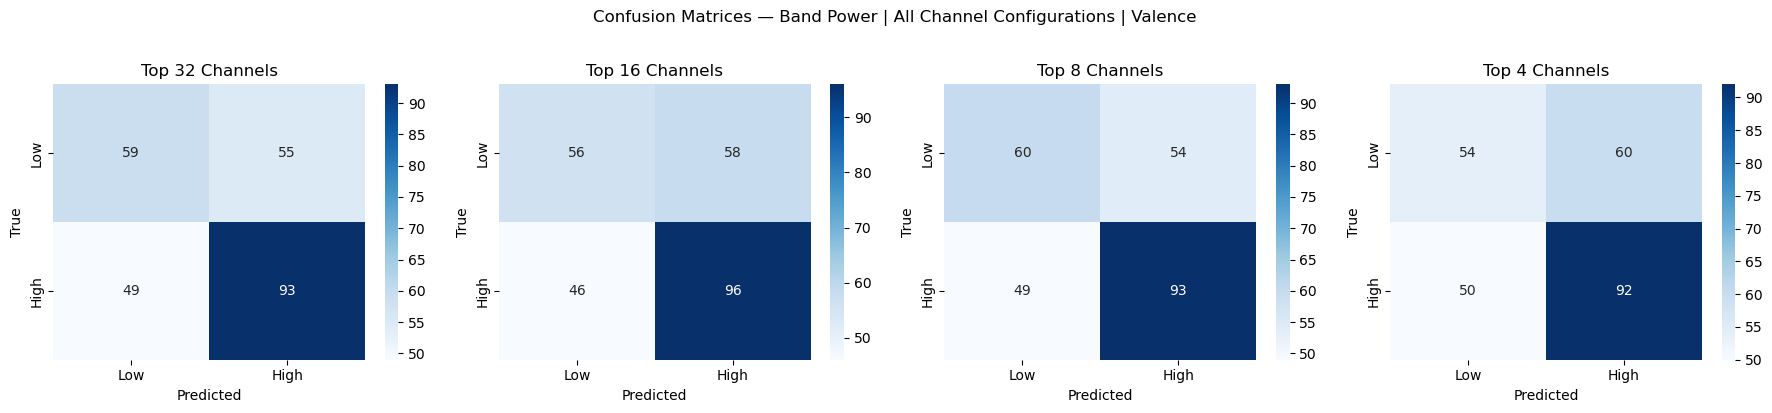

Best Configuration : Top 32 Channels
CV Mean Accuracy   : 0.6461 ± 0.0174
Hold-out Accuracy  : 0.5938

Saved → valence_band_model.pkl
Saved → valence_band_scaler.pkl

Class distribution (Arousal) : [543 737]  → [Low, High]

######################################################################
#  RUNNING PIPELINE FOR: AROUSAL
######################################################################
Train set : (1024, 160)
Test  set : (256, 160)
Scaler saved → arousal_band_scaler_32ch.pkl
Training complete.
Accuracy  : 0.6211
Precision : 0.6582
Recall    : 0.7075
F1-Score  : 0.6820

Classification Report:
              precision    recall  f1-score   support

 Low Arousal       0.56      0.50      0.53       109
High Arousal       0.66      0.71      0.68       147

    accuracy                           0.62       256
   macro avg       0.61      0.61      0.61       256
weighted avg       0.62      0.62      0.62       256

Confusion Matrix:
[[ 55  54]
 [ 43 104]]
Fold Scores   : [0.6562

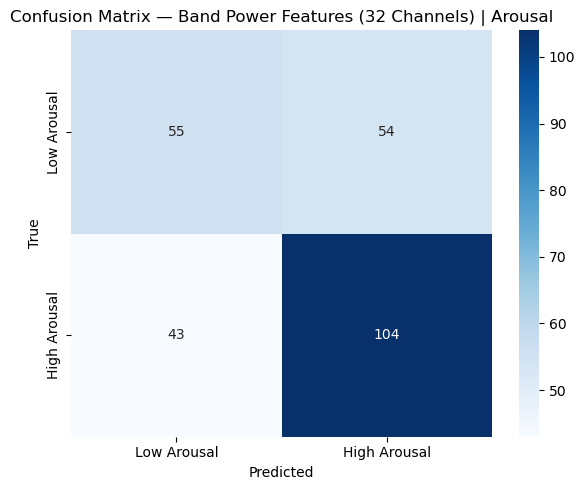

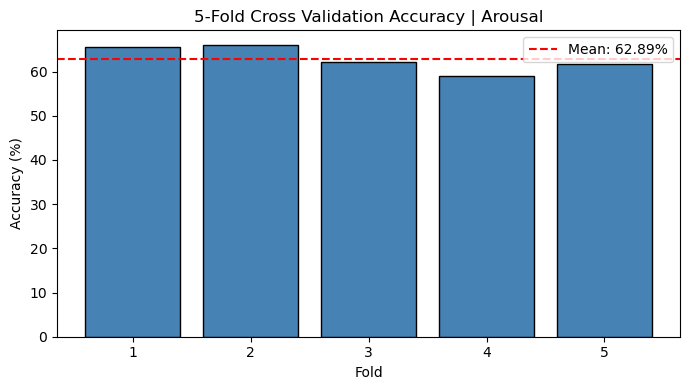

       Channel     Score
0   Channel_13  0.041457
1   Channel_20  0.035874
2    Channel_3  0.034761
3   Channel_18  0.034288
4   Channel_22  0.034029
5   Channel_26  0.033888
6   Channel_15  0.033208
7   Channel_11  0.032908
8    Channel_6  0.032374
9   Channel_23  0.032254
10   Channel_9  0.032252
11  Channel_29  0.032181
12  Channel_12  0.032096
13   Channel_8  0.032065
14  Channel_31  0.031483
15  Channel_14  0.030889
16  Channel_19  0.030529
17  Channel_16  0.030468
18  Channel_30  0.029932
19  Channel_17  0.029799
20   Channel_7  0.029653
21   Channel_1  0.029296
22  Channel_28  0.029295
23   Channel_5  0.029236
24  Channel_21  0.028796
25  Channel_32  0.028683
26  Channel_10  0.028671
27  Channel_27  0.028608
28   Channel_4  0.028080
29  Channel_25  0.028073
30   Channel_2  0.027706
31  Channel_24  0.027166


C:\Users\Sayantan\AppData\Local\Temp\ipykernel_21212\2008507769.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_ranking, x="Channel", y="Score",


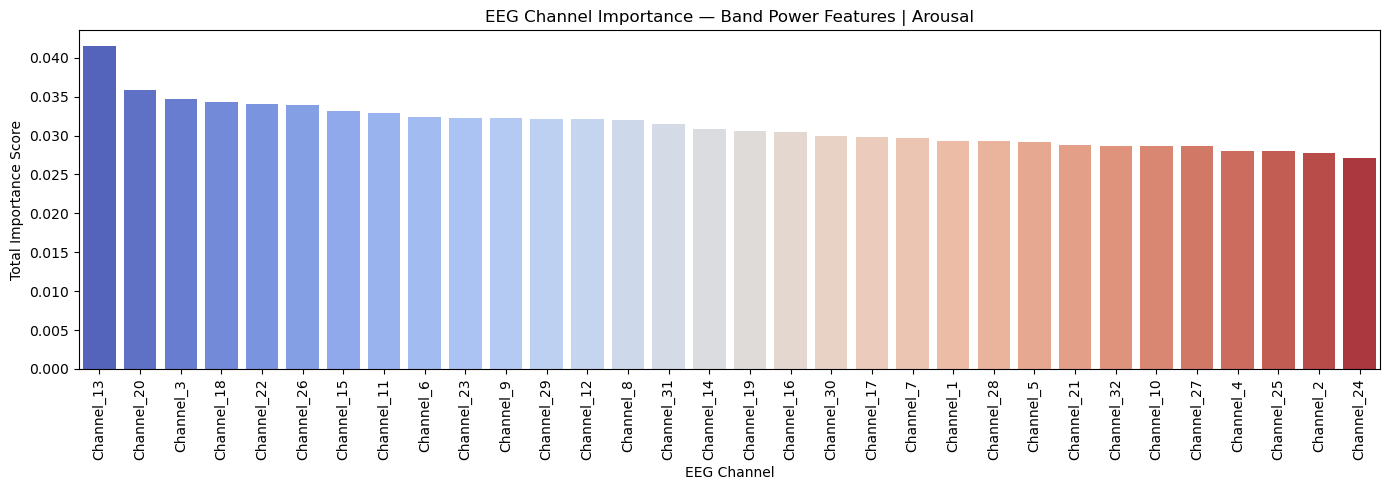

Top 4  channels: [13, 20, 3, 18]
Top 8  channels: [13, 20, 3, 18, 22, 26, 15, 11]
Top 16 channels: [13, 20, 3, 18, 22, 26, 15, 11, 6, 23, 9, 29, 12, 8, 31, 14]

  Arousal | Top 32 Channels
  Accuracy  : 0.6289  |  Precision : 0.6566
  Recall    : 0.7415  |  F1-Score  : 0.6965
  CV Accuracy : 0.6227 ± 0.0249

  Classification Report:
              precision    recall  f1-score   support

 Low Arousal       0.58      0.48      0.52       109
High Arousal       0.66      0.74      0.70       147

    accuracy                           0.63       256
   macro avg       0.62      0.61      0.61       256
weighted avg       0.62      0.63      0.62       256


  Arousal | Top 16 Channels
  Accuracy  : 0.6406  |  Precision : 0.6752
  Recall    : 0.7211  |  F1-Score  : 0.6974
  CV Accuracy : 0.6297 ± 0.0274

  Classification Report:
              precision    recall  f1-score   support

 Low Arousal       0.59      0.53      0.56       109
High Arousal       0.68      0.72      0.70       147


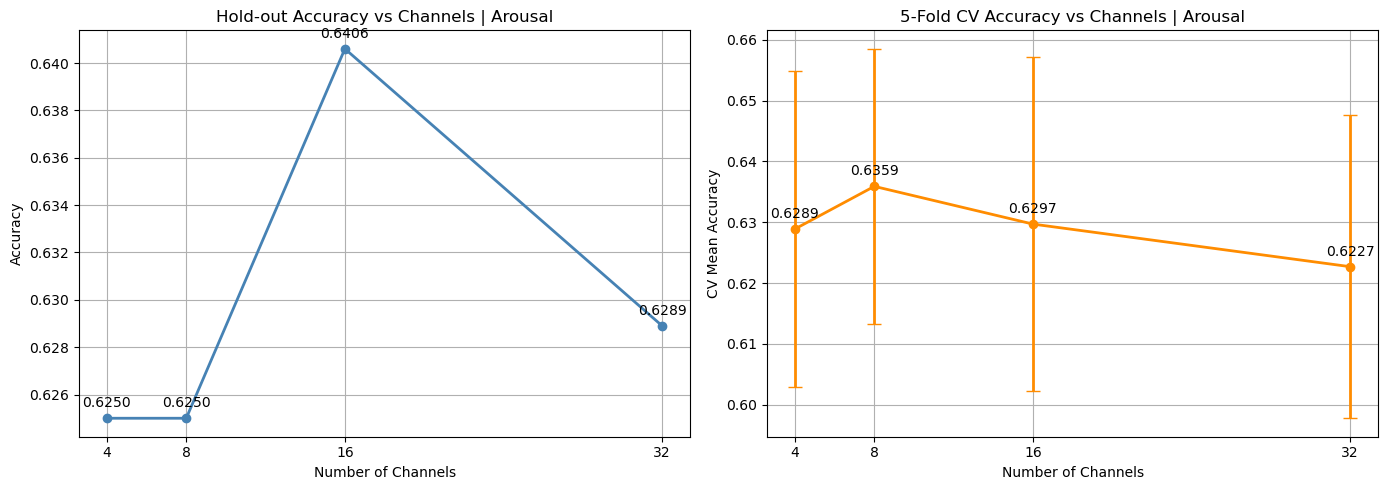

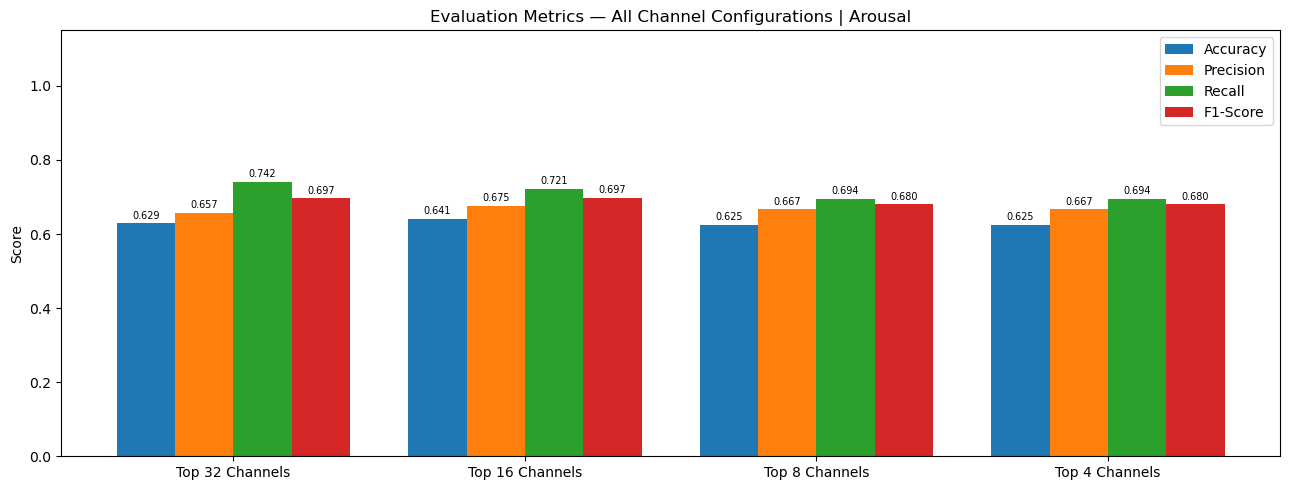

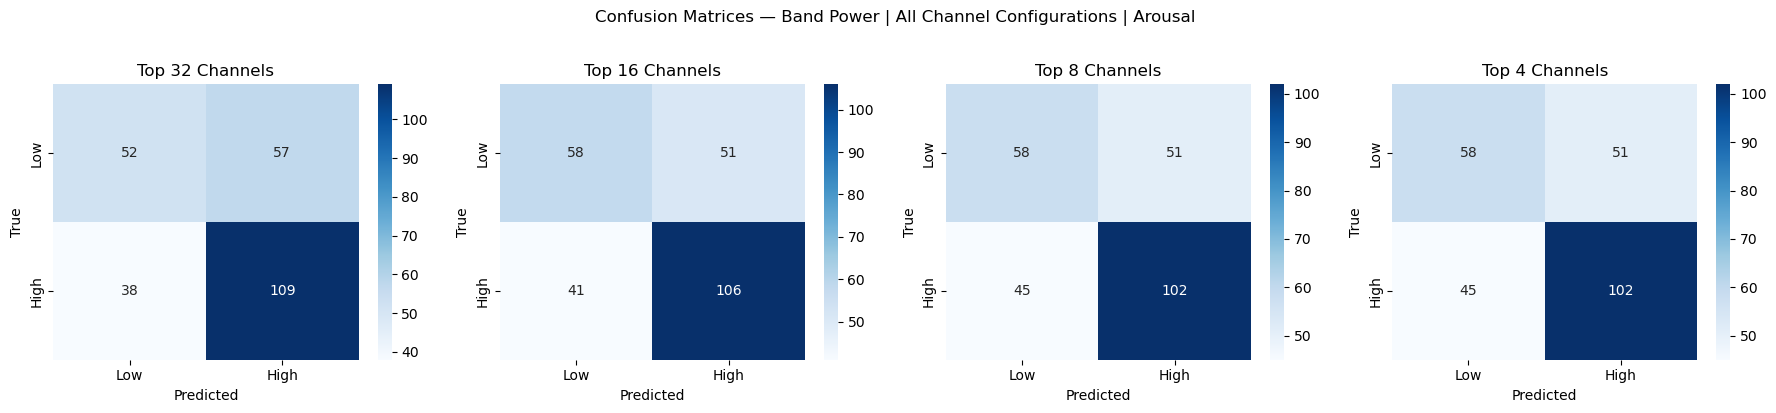

Best Configuration : Top 8 Channels
CV Mean Accuracy   : 0.6359 ± 0.0226
Hold-out Accuracy  : 0.6250

Saved → arousal_band_model.pkl
Saved → arousal_band_scaler.pkl

Class distribution (Dominance) : [500 780]  → [Low, High]

######################################################################
#  RUNNING PIPELINE FOR: DOMINANCE
######################################################################
Train set : (1024, 160)
Test  set : (256, 160)
Scaler saved → dominance_band_scaler_32ch.pkl
Training complete.
Accuracy  : 0.6992
Precision : 0.7182
Recall    : 0.8333
F1-Score  : 0.7715

Classification Report:
                precision    recall  f1-score   support

 Low Dominance       0.65      0.49      0.56       100
High Dominance       0.72      0.83      0.77       156

      accuracy                           0.70       256
     macro avg       0.69      0.66      0.67       256
  weighted avg       0.69      0.70      0.69       256

Confusion Matrix:
[[ 49  51]
 [ 26 130]]
Fold S

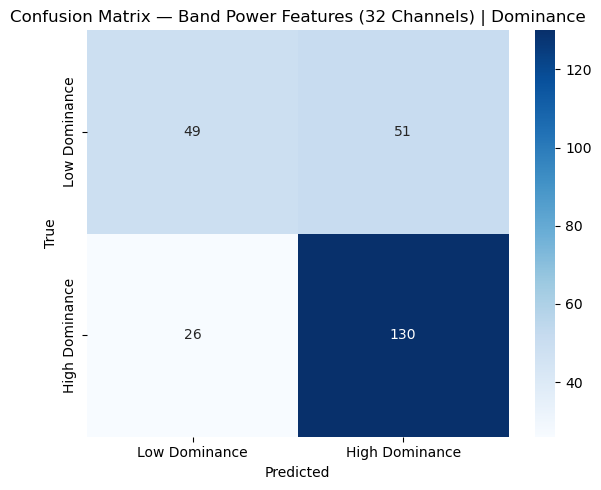

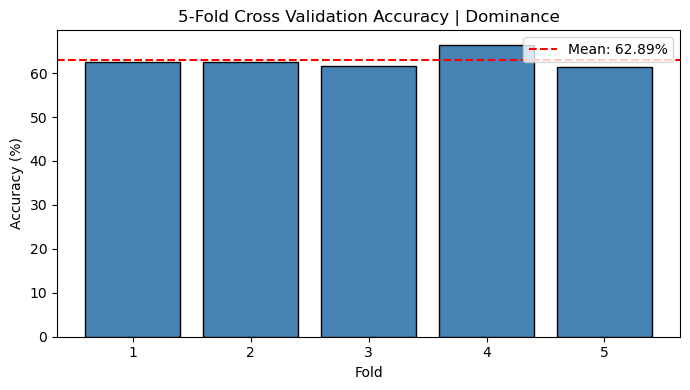

       Channel     Score
0   Channel_27  0.041993
1    Channel_1  0.035921
2    Channel_4  0.035410
3   Channel_15  0.034760
4    Channel_3  0.034463
5    Channel_8  0.034297
6   Channel_23  0.033298
7    Channel_2  0.033023
8   Channel_24  0.032286
9   Channel_29  0.032237
10   Channel_6  0.032233
11  Channel_17  0.032004
12  Channel_10  0.031975
13   Channel_9  0.031151
14  Channel_26  0.031033
15  Channel_16  0.030954
16  Channel_13  0.030794
17  Channel_32  0.030603
18   Channel_5  0.030554
19  Channel_28  0.030139
20   Channel_7  0.030026
21  Channel_12  0.029675
22  Channel_19  0.029654
23  Channel_14  0.029488
24  Channel_30  0.029470
25  Channel_21  0.028719
26  Channel_31  0.028451
27  Channel_25  0.028372
28  Channel_18  0.028188
29  Channel_22  0.028102
30  Channel_20  0.026621
31  Channel_11  0.024107


C:\Users\Sayantan\AppData\Local\Temp\ipykernel_21212\2008507769.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_ranking, x="Channel", y="Score",


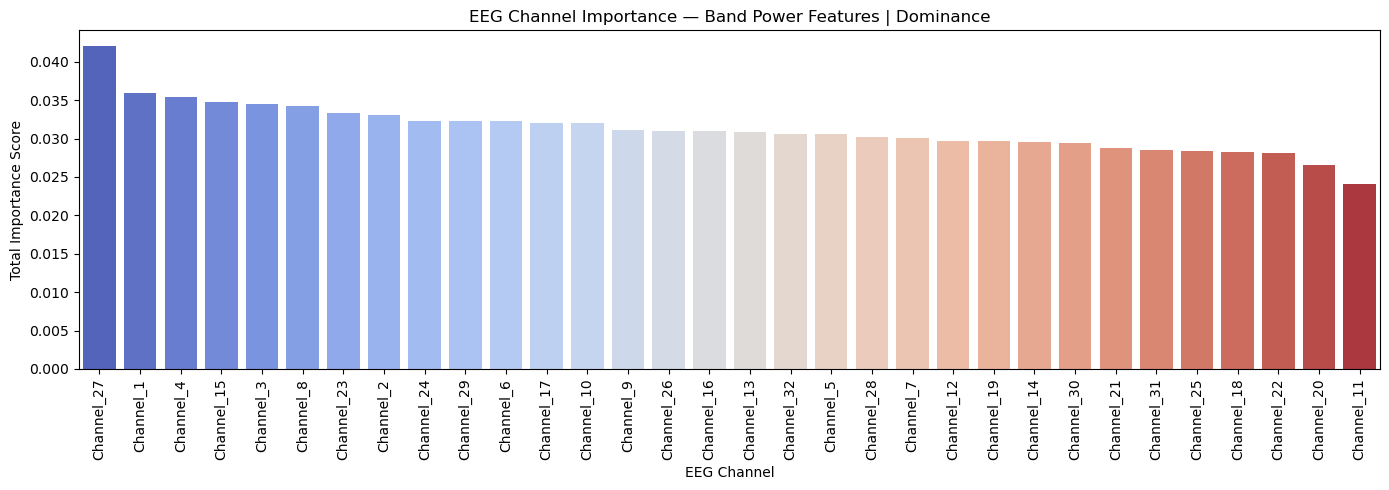

Top 4  channels: [27, 1, 4, 15]
Top 8  channels: [27, 1, 4, 15, 3, 8, 23, 2]
Top 16 channels: [27, 1, 4, 15, 3, 8, 23, 2, 24, 29, 6, 17, 10, 9, 26, 16]

  Dominance | Top 32 Channels
  Accuracy  : 0.6797  |  Precision : 0.7011
  Recall    : 0.8269  |  F1-Score  : 0.7588
  CV Accuracy : 0.6320 ± 0.0226

  Classification Report:
                precision    recall  f1-score   support

 Low Dominance       0.62      0.45      0.52       100
High Dominance       0.70      0.83      0.76       156

      accuracy                           0.68       256
     macro avg       0.66      0.64      0.64       256
  weighted avg       0.67      0.68      0.67       256


  Dominance | Top 16 Channels
  Accuracy  : 0.6758  |  Precision : 0.6995
  Recall    : 0.8205  |  F1-Score  : 0.7552
  CV Accuracy : 0.6297 ± 0.0177

  Classification Report:
                precision    recall  f1-score   support

 Low Dominance       0.62      0.45      0.52       100
High Dominance       0.70      0.82      0

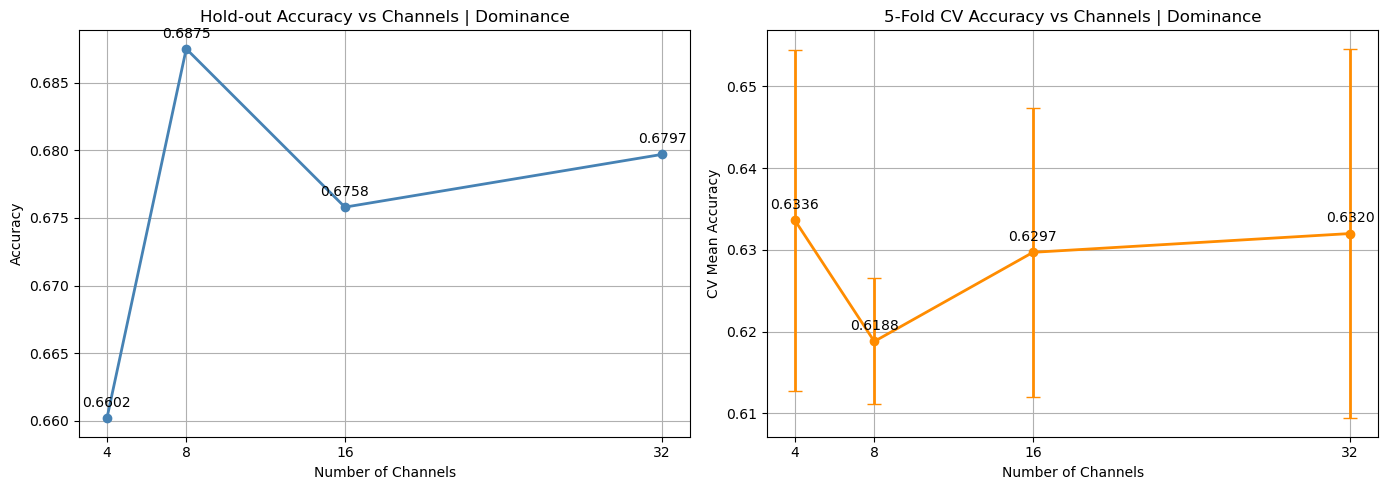

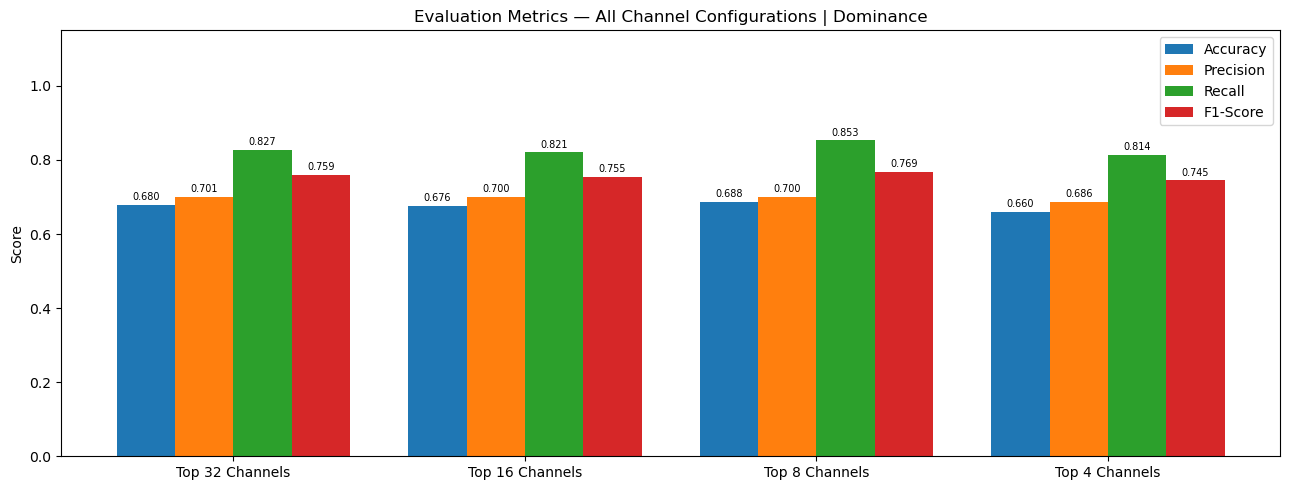

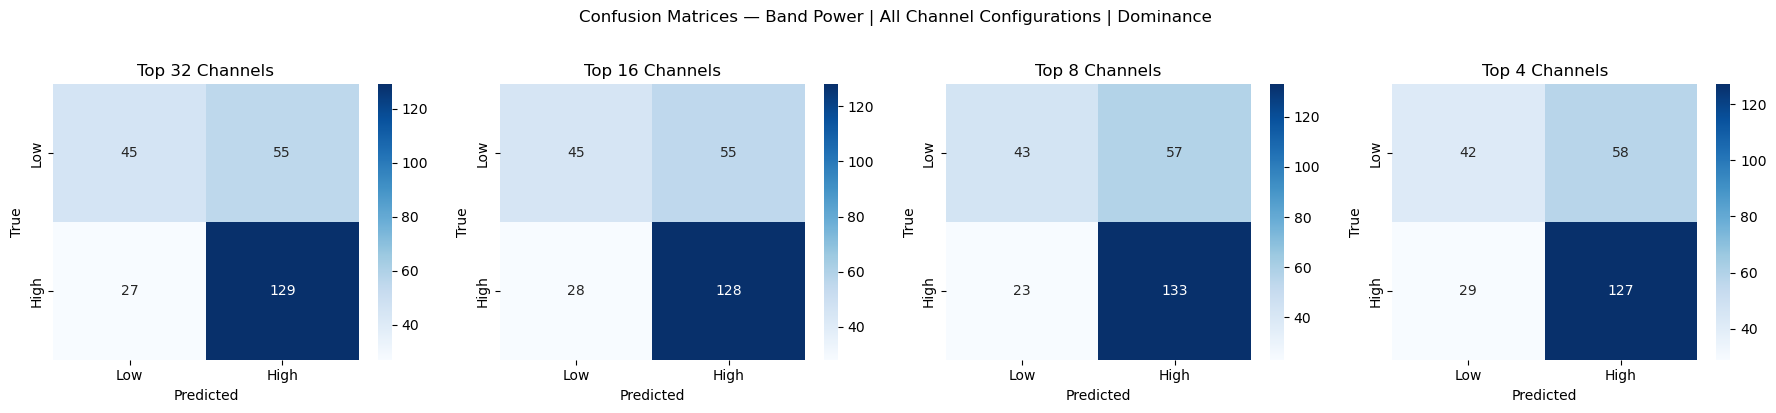

Best Configuration : Top 4 Channels
CV Mean Accuracy   : 0.6336 ± 0.0209
Hold-out Accuracy  : 0.6602

Saved → dominance_band_model.pkl
Saved → dominance_band_scaler.pkl

Class distribution (Liking) : [429 851]  → [Low, High]

######################################################################
#  RUNNING PIPELINE FOR: LIKING
######################################################################
Train set : (1024, 160)
Test  set : (256, 160)
Scaler saved → liking_band_scaler_32ch.pkl
Training complete.
Accuracy  : 0.6719
Precision : 0.7048
Recall    : 0.8706
F1-Score  : 0.7789

Classification Report:
              precision    recall  f1-score   support

  Low Liking       0.52      0.28      0.36        86
 High Liking       0.70      0.87      0.78       170

    accuracy                           0.67       256
   macro avg       0.61      0.57      0.57       256
weighted avg       0.64      0.67      0.64       256

Confusion Matrix:
[[ 24  62]
 [ 22 148]]
Fold Scores   : [0.6641

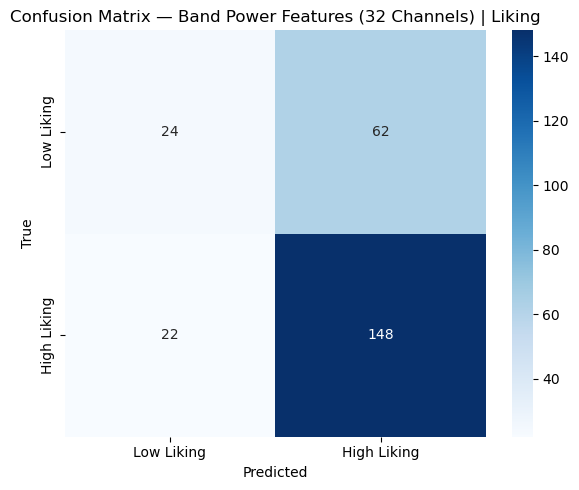

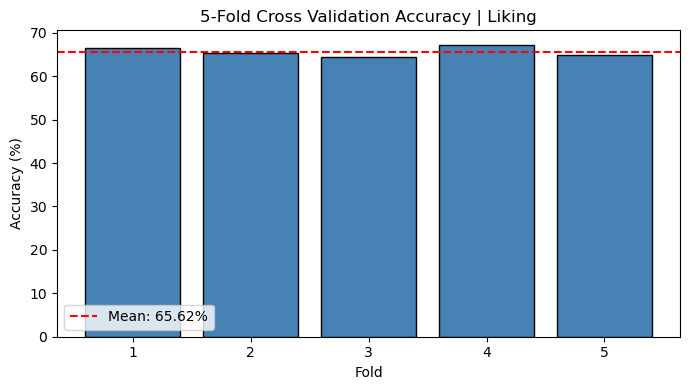

       Channel     Score
0   Channel_25  0.036603
1   Channel_11  0.036603
2   Channel_21  0.035931
3   Channel_18  0.035636
4   Channel_32  0.035282
5   Channel_14  0.033427
6   Channel_12  0.033421
7   Channel_30  0.033218
8    Channel_1  0.033027
9   Channel_17  0.032847
10  Channel_19  0.032710
11  Channel_29  0.032074
12  Channel_15  0.032020
13   Channel_7  0.031389
14   Channel_9  0.031119
15   Channel_6  0.031102
16   Channel_3  0.030755
17  Channel_26  0.030544
18  Channel_31  0.030540
19   Channel_4  0.030221
20  Channel_13  0.030124
21  Channel_20  0.029973
22  Channel_28  0.029902
23   Channel_2  0.029885
24  Channel_23  0.029091
25  Channel_24  0.028225
26  Channel_22  0.028163
27  Channel_16  0.028079
28   Channel_5  0.027781
29  Channel_27  0.027564
30   Channel_8  0.027288
31  Channel_10  0.025456


C:\Users\Sayantan\AppData\Local\Temp\ipykernel_21212\2008507769.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_ranking, x="Channel", y="Score",


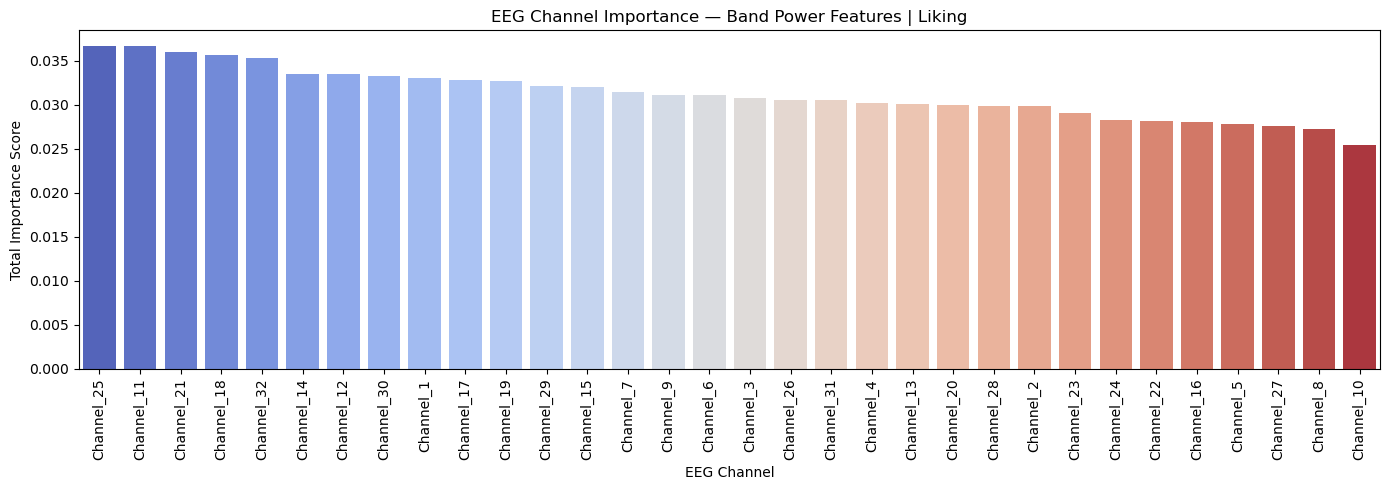

Top 4  channels: [25, 11, 21, 18]
Top 8  channels: [25, 11, 21, 18, 32, 14, 12, 30]
Top 16 channels: [25, 11, 21, 18, 32, 14, 12, 30, 1, 17, 19, 29, 15, 7, 9, 6]

  Liking | Top 32 Channels
  Accuracy  : 0.6680  |  Precision : 0.7094
  Recall    : 0.8471  |  F1-Score  : 0.7721
  CV Accuracy : 0.6555 ± 0.0172

  Classification Report:
              precision    recall  f1-score   support

  Low Liking       0.51      0.31      0.39        86
 High Liking       0.71      0.85      0.77       170

    accuracy                           0.67       256
   macro avg       0.61      0.58      0.58       256
weighted avg       0.64      0.67      0.64       256


  Liking | Top 16 Channels
  Accuracy  : 0.6836  |  Precision : 0.7171
  Recall    : 0.8647  |  F1-Score  : 0.7840
  CV Accuracy : 0.6586 ± 0.0120

  Classification Report:
              precision    recall  f1-score   support

  Low Liking       0.55      0.33      0.41        86
 High Liking       0.72      0.86      0.78       170


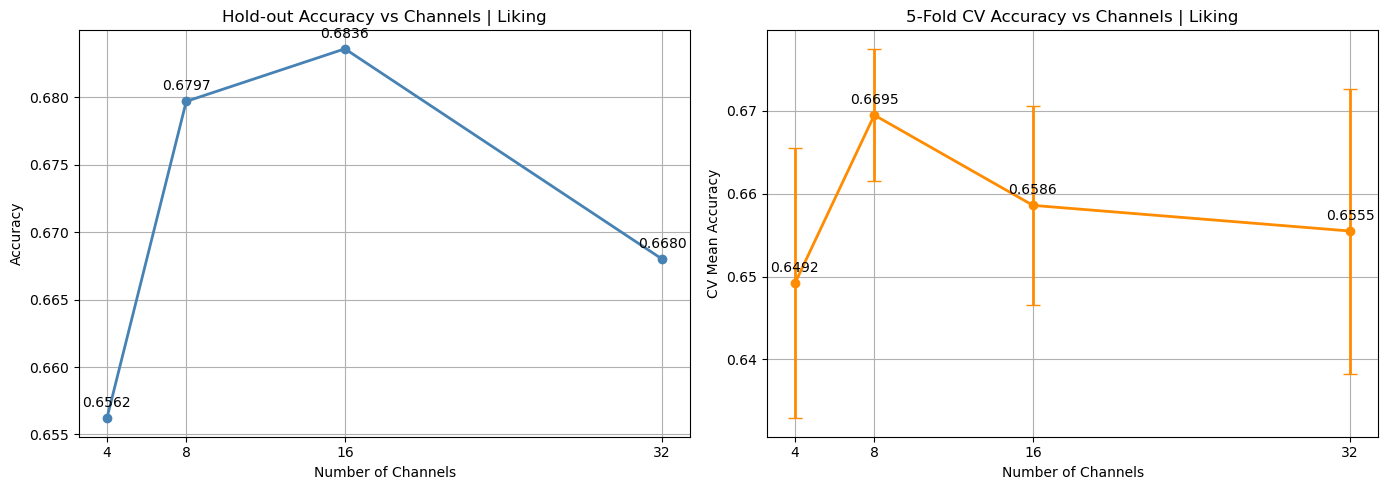

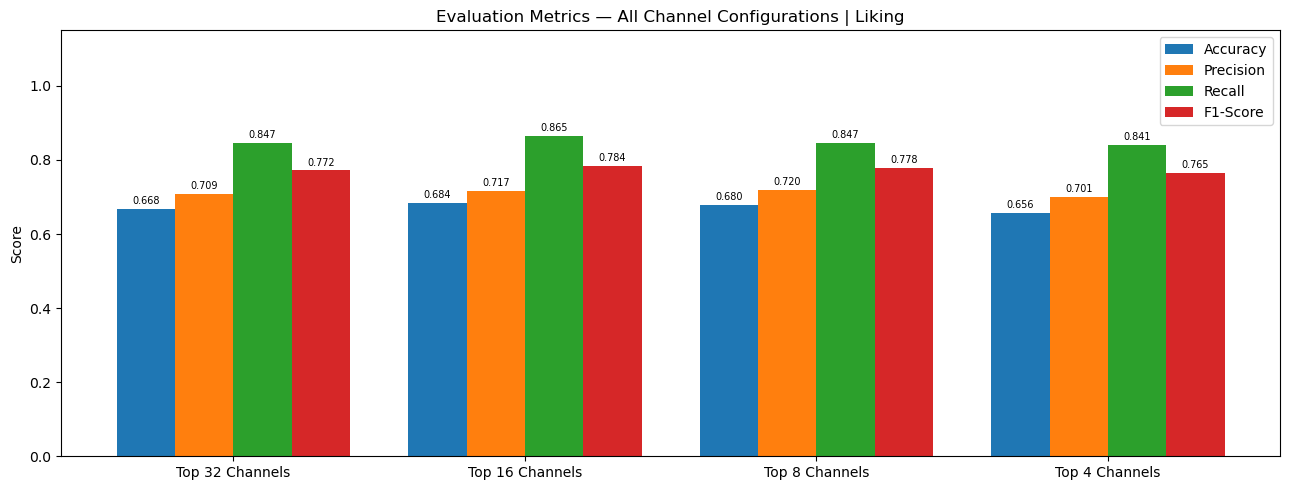

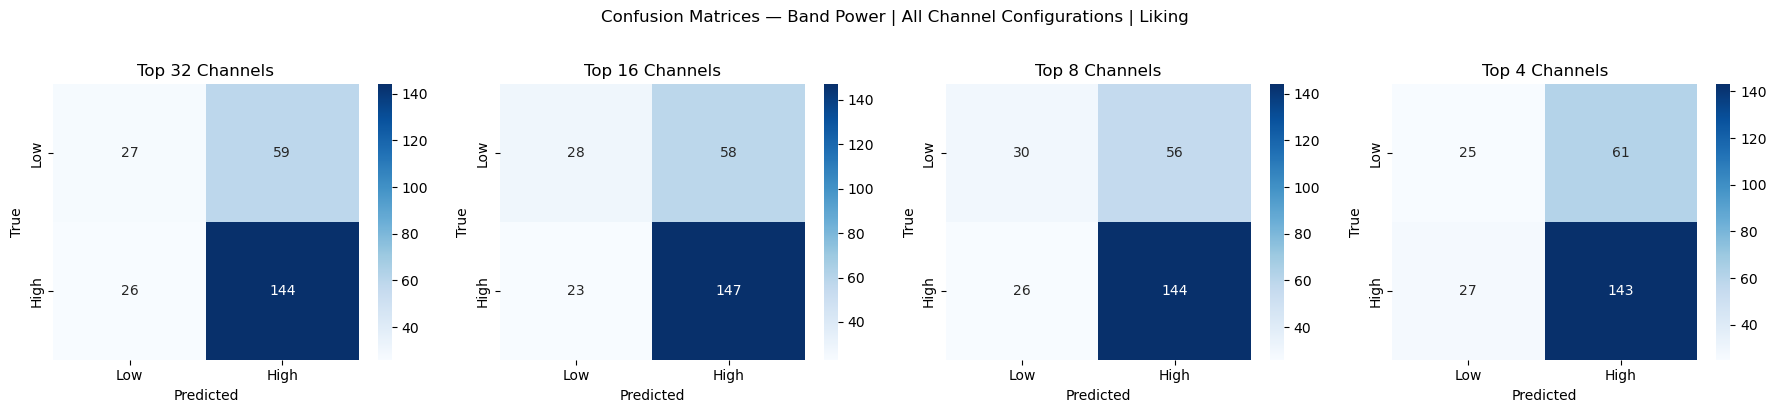

Best Configuration : Top 8 Channels
CV Mean Accuracy   : 0.6695 ± 0.0080
Hold-out Accuracy  : 0.6797

Saved → liking_band_model.pkl
Saved → liking_band_scaler.pkl


In [6]:
# ============================================================
# CELL 6  (NEW — run the pipeline automatically for all 4 emotions)
# ============================================================
all_emotion_results = {}

for emotion_name, col_idx in EMOTIONS.items():
    y_emotion = (labels[:, col_idx] > 5).astype(int)
    print(f"\nClass distribution ({emotion_name}) :", np.bincount(y_emotion), " → [Low, High]")
    all_emotion_results[emotion_name] = run_pipeline_for_emotion(emotion_name, y_emotion)

In [7]:
# ============================================================
# CELL 7  (NEW — final summary table across all emotions)
# ============================================================
summary_rows = []
for emotion_name, res in all_emotion_results.items():
    b = res["best"]
    summary_rows.append({
        "Emotion"             : emotion_name,
        "Best Channel Config" : b["Configuration"],
        "Num Features"        : b["Features"],
        "Accuracy"            : b["Accuracy"],
        "Precision"           : b["Precision"],
        "Recall"              : b["Recall"],
        "F1-Score"            : b["F1-Score"],
        "CV Mean"             : b["CV Mean"],
        "CV Std"              : b["CV Std"],
        "Best Accuracy"       : b["Accuracy"],
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "="*90)
print("FINAL SUMMARY — BEST CONFIGURATION PER EMOTION")
print("="*90)
print(summary_df.to_string(index=False))

summary_df.to_csv("emotion_summary_band.csv", index=False)
print("\nSaved → emotion_summary_band.csv")


FINAL SUMMARY — BEST CONFIGURATION PER EMOTION
  Emotion Best Channel Config  Num Features  Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std  Best Accuracy
  Valence     Top 32 Channels           160    0.5938     0.6284  0.6549    0.6414   0.6461  0.0174         0.5938
  Arousal      Top 8 Channels            40    0.6250     0.6667  0.6939    0.6800   0.6359  0.0226         0.6250
Dominance      Top 4 Channels            20    0.6602     0.6865  0.8141    0.7449   0.6336  0.0209         0.6602
   Liking      Top 8 Channels            40    0.6797     0.7200  0.8471    0.7784   0.6695  0.0080         0.6797

Saved → emotion_summary_band.csv
